# PRT565 - Assessment 2: Machine Learning Coding Exercise

**Name:** OShan Thapa Chhetri
**Student ID:** S395087
**Campus:** Sydney 
**Unit:** PRT565 - Machine Learning, Artificial Intelligence and Algorithms

**Dataset:** Netflix Movies and TV Shows (`netflix_titles.csv`)
**Goal:** Predict whether a Netflix title is a **Movie** or a **TV Show** using its
metadata (release year, rating, genre, country, and when it was added to Netflix),
using Logistic Regression, Decision Tree, and Random Forest classifiers.

In [ ]:
# Core data handling libraries
import pandas as pd
import numpy as np
import os

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ML models required by the assessment brief
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make plots render inline and set a consistent style
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Load the Dataset

In [ ]:
# Load the Netflix titles dataset (sourced from Kaggle:
# https://www.kaggle.com/datasets/shivamb/netflix-shows)

df = pd.read_csv('netflix_titles.csv')

# Quick look at the first few rows to confirm it loaded correctly
df.head()

Current working directory: C:\Users\oshan\AppData\Local\Programs\Microsoft VS Code


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\oshan\\xhhetri-CDU_third_sem_assignments\\PRT565 - Machine Learning, Artificial Intelligence and Algorithms'

## 3. Initial Data Analysis and Exploration

In [ ]:
# Analysis: shape of the dataset (rows, columns)
print("Total records:", len(df))
print("Total columns:", df.shape[1])

In [ ]:
# Analysis: column data types and non-null counts
df.info()

In [ ]:
# Analysis: descriptive statistics for the numeric column(s)
df.describe()

In [ ]:
# Analysis: how many missing (null) values are present in each column
df.isnull().sum()

In [ ]:
# Analysis: class balance of our target variable 'type'
# This matters because an imbalanced target can bias accuracy as a metric
print(df['type'].value_counts())
print(df['type'].value_counts(normalize=True).round(3) * 100, "%")

In [ ]:
# Visualisation: bar chart of Movie vs TV Show counts
sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)
plt.title('Distribution of Content Type (Movie vs TV Show)')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

In [ ]:
# Visualisation: how content ratings (e.g. TV-MA, PG-13) are distributed
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, hue='rating', palette='viridis', legend=False)
plt.title('Distribution of Content Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

In [ ]:
# Visualisation: number of titles released per year (last 20 years) split by type
recent = df[df['release_year'] >= 2000]
plt.figure(figsize=(12, 5))
sns.countplot(data=recent, x='release_year', hue='type', palette='Set1')
plt.title('Titles Released per Year by Type (2000 onwards)')
plt.xticks(rotation=90)
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

In [ ]:
# Analysis: top 10 genres in the dataset (a title can have multiple genres,
# separated by commas in 'listed_in', so we look at the first-listed genre)
top_genres_preview = df['listed_in'].str.split(',').str[0].str.strip().value_counts().head(10)
print(top_genres_preview)

## 4. Data Cleaning and Pre-processing

Before we can build any model, the raw data needs to be cleaned. The steps below
were chosen based on what the exploration above revealed:

1. **Fix a data-entry error**: three rows have a duration value (e.g. `'74 min'`)
   sitting in the `rating` column instead of the `duration` column. We correct this
   by moving the value across.
2. **Drop rows with only a handful of missing values** (`date_added`, `duration`,
   `rating`) since these are a tiny fraction of ~8,800 rows and dropping them is
   safer than guessing a value.
3. **Impute `country`** with `'Unknown'` since ~9% of rows are missing it and
   dropping them would lose too much data.
4. **`director` and `cast` are dropped entirely** — they are highly sparse
   (director is missing in ~30% of rows) and are high-cardinality free-text
   fields that are not suitable as structured ML features without heavy NLP
   pre-processing, which is outside the scope of this exercise.

In [ ]:
# Cleaning: locate and fix the 3 misaligned rows identified during exploration
# (rows where a duration string like '74 min' was mistakenly stored in 'rating')
misaligned_mask = df['rating'].isin(['74 min', '84 min', '66 min'])
print("Misaligned rows found:", misaligned_mask.sum())

df.loc[misaligned_mask, 'duration'] = df.loc[misaligned_mask, 'rating']
df.loc[misaligned_mask, 'rating'] = np.nan

# Verify the fix worked
df.loc[misaligned_mask, ['type', 'rating', 'duration']]

In [ ]:
# Cleaning: drop rows with missing date_added, duration, or rating
# These are a very small fraction of the dataset so dropping is safe
before = len(df)
df = df.dropna(subset=['date_added', 'duration', 'rating']).copy()
after = len(df)
print(f"Rows before cleaning: {before}, rows after cleaning: {after}, rows dropped: {before - after}")

In [ ]:
# Cleaning: impute missing 'country' values with 'Unknown' rather than dropping
# them, since almost 9% of the dataset would otherwise be lost
df['country'] = df['country'].fillna('Unknown')

# Drop the high-cardinality, heavily-missing free-text columns that are not
# useful as structured features for this exercise
df = df.drop(columns=['director', 'cast'])

# Confirm no more nulls remain in the columns we plan to use
df[['country', 'date_added', 'rating', 'duration', 'listed_in']].isnull().sum()

## 5. Feature Engineering

Several raw columns are not directly usable by a model and need to be transformed
into numeric features:

- `country` often lists several countries (comma-separated) — we keep only the
  **primary (first-listed) country** and group anything outside the top 10 into `'Other'`.
- `listed_in` (genre) is treated the same way: **primary genre**, top 10 kept, rest grouped as `'Other'`.
- `date_added` is converted to a `year_added` feature.
- `duration` is stored as text (e.g. `'90 min'` or `'2 Seasons'`) — we extract just
  the **numeric value** so it can be used as a continuous feature.
- `type` (our target) is label-encoded: `Movie = 0`, `TV Show = 1`.

In [ ]:
# Feature engineering: primary country (first country listed), grouped to top 10 + 'Other'
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()
top_countries = df['primary_country'].value_counts().nlargest(10).index
df['primary_country'] = df['primary_country'].where(df['primary_country'].isin(top_countries), 'Other')

print(df['primary_country'].value_counts())

In [ ]:
# Feature engineering: primary genre (first genre listed), grouped to top 10 + 'Other'
df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()
top_genres = df['primary_genre'].value_counts().nlargest(10).index
df['primary_genre'] = df['primary_genre'].where(df['primary_genre'].isin(top_genres), 'Other')

print(df['primary_genre'].value_counts())

primary_genre
Dramas                      1599
Other                       1522
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       773
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     385
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64


In [ ]:
# Feature engineering: extract the year a title was added to Netflix
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year

df[['date_added', 'year_added']].head()

,date_added,year_added
0,2021-09-25,2021
1,2021-09-24,2021
2,2021-09-24,2021
3,2021-09-24,2021
4,2021-09-24,2021


In [ ]:
# Feature engineering: extract the numeric portion of 'duration'
# (works for both '90 min' -> 90 and '2 Seasons' -> 2)
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)

df[['type', 'duration', 'duration_value']].head()

,type,duration,duration_value
0,Movie,90 min,90.0
1,TV Show,2 Seasons,2.0
2,TV Show,1 Season,1.0
3,TV Show,1 Season,1.0
4,TV Show,2 Seasons,2.0


In [ ]:
# Target encoding: Movie = 0, TV Show = 1
df['type_encoded'] = df['type'].map({'Movie': 0, 'TV Show': 1})

df['type_encoded'].value_counts()

type_encoded
0    6126
1    2664
Name: count, dtype: int64

In [ ]:
# Categorical encoding: convert text categories into numbers using LabelEncoder
# so they can be used by the ML algorithms
le_rating = LabelEncoder()
df['rating_encoded'] = le_rating.fit_transform(df['rating'])

le_country = LabelEncoder()
df['country_encoded'] = le_country.fit_transform(df['primary_country'])

le_genre = LabelEncoder()
df['genre_encoded'] = le_genre.fit_transform(df['primary_genre'])

df[['rating', 'rating_encoded', 'primary_country', 'country_encoded',
    'primary_genre', 'genre_encoded']].head()

,rating,rating_encoded,primary_country,country_encoded,primary_genre,genre_encoded
0,PG-13,4,United States,9,Documentaries,4
1,TV-MA,8,Other,5,International TV Shows,7
2,TV-MA,8,Unknown,10,Crime TV Shows,3
3,TV-MA,8,Unknown,10,Other,9
4,TV-MA,8,India,2,International TV Shows,7


In [ ]:
# Final check: the cleaned and engineered dataframe is now ready for modelling
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8790 non-null   object        
 1   type             8790 non-null   object        
 2   title            8790 non-null   object        
 3   country          8790 non-null   object        
 4   date_added       8790 non-null   datetime64[ns]
 5   release_year     8790 non-null   int64         
 6   rating           8790 non-null   object        
 7   duration         8790 non-null   object        
 8   listed_in        8790 non-null   object        
 9   description      8790 non-null   object        
 10  primary_country  8790 non-null   object        
 11  primary_genre    8790 non-null   object        
 12  year_added       8790 non-null   int32         
 13  duration_value   8790 non-null   float64       
 14  type_encoded     8790 non-null   int64       

## 6. Defining Feature Sets (X) and Target (y)

We deliberately build **two feature sets** to compare:

- **Feature Set A ("without duration")**: `release_year`, `year_added`,
  `rating_encoded`, `country_encoded`, `genre_encoded`
- **Feature Set B ("with duration")**: Feature Set A **plus** `duration_value`

This is because `duration` almost gives the answer away on its own (movies are
measured in minutes, ~60-300+, while TV shows are measured in seasons, ~1-17),
so comparing the two feature sets lets us clearly see and discuss this **data
leakage** effect in the results section.

In [ ]:
# Target variable
y = df['type_encoded']

# Feature Set A: without duration (more realistic, harder problem)
features_A = ['release_year', 'year_added', 'rating_encoded', 'country_encoded', 'genre_encoded']
X_A = df[features_A]

# Feature Set B: with duration (duration leaks the answer almost directly)
features_B = features_A + ['duration_value']
X_B = df[features_B]

print("Feature Set A columns:", list(X_A.columns))
print("Feature Set B columns:", list(X_B.columns))

Feature Set A columns: ['release_year', 'year_added', 'rating_encoded', 'country_encoded', 'genre_encoded']
Feature Set B columns: ['release_year', 'year_added', 'rating_encoded', 'country_encoded', 'genre_encoded', 'duration_value']


## 7. Splitting the Dataset into Training and Testing sets

Both feature sets are split using a **70/30 train-test split**. `stratify=y` is
used to ensure the Movie/TV Show ratio is preserved in both the training and
testing sets, and `random_state=42` is fixed so the results are reproducible.

In [ ]:
# Split Feature Set A
X_A_train, X_A_test, y_train, y_test = train_test_split(
    X_A, y, test_size=0.3, random_state=42, stratify=y
)

# Split Feature Set B (same random_state/stratify so the split is comparable)
X_B_train, X_B_test, _, _ = train_test_split(
    X_B, y, test_size=0.3, random_state=42, stratify=y
)

print("Feature Set A -> Train:", X_A_train.shape, " Test:", X_A_test.shape)
print("Feature Set B -> Train:", X_B_train.shape, " Test:", X_B_test.shape)

Feature Set A -> Train: (6153, 5)  Test: (2637, 5)
Feature Set B -> Train: (6153, 6)  Test: (2637, 6)


In [ ]:
# Feature scaling (standardisation) is required for Logistic Regression,
# which is sensitive to the scale of input features. Tree-based models
# (Decision Tree, Random Forest) do not require scaling, so we keep an
# unscaled copy for them.
scaler_A = StandardScaler()
X_A_train_scaled = scaler_A.fit_transform(X_A_train)
X_A_test_scaled = scaler_A.transform(X_A_test)

scaler_B = StandardScaler()
X_B_train_scaled = scaler_B.fit_transform(X_B_train)
X_B_test_scaled = scaler_B.transform(X_B_test)

print("Scaling complete.")

Scaling complete.


## 8. Logistic Regression Model

Logistic Regression models the probability that a title is a TV Show (1) versus
a Movie (0), given the input features.

In [ ]:
# Logistic Regression - Feature Set A (without duration)
lr_A = LogisticRegression(max_iter=1000)
lr_A.fit(X_A_train_scaled, y_train)
y_pred_lr_A = lr_A.predict(X_A_test_scaled)
acc_lr_A = accuracy_score(y_test, y_pred_lr_A)

print("Logistic Regression accuracy (without duration):", round(acc_lr_A, 4))
print(classification_report(y_test, y_pred_lr_A, target_names=['Movie', 'TV Show']))

Logistic Regression accuracy (without duration): 0.8343
              precision    recall  f1-score   support

       Movie       0.86      0.91      0.88      1838
     TV Show       0.76      0.67      0.71       799

    accuracy                           0.83      2637
   macro avg       0.81      0.79      0.80      2637
weighted avg       0.83      0.83      0.83      2637



In [ ]:
# Logistic Regression - Feature Set B (with duration)
lr_B = LogisticRegression(max_iter=1000)
lr_B.fit(X_B_train_scaled, y_train)
y_pred_lr_B = lr_B.predict(X_B_test_scaled)
acc_lr_B = accuracy_score(y_test, y_pred_lr_B)

print("Logistic Regression accuracy (with duration):", round(acc_lr_B, 4))
print(classification_report(y_test, y_pred_lr_B, target_names=['Movie', 'TV Show']))

Logistic Regression accuracy (with duration): 0.9981
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1838
     TV Show       0.99      1.00      1.00       799

    accuracy                           1.00      2637
   macro avg       1.00      1.00      1.00      2637
weighted avg       1.00      1.00      1.00      2637



## 9. Decision Tree Model

The Decision Tree classifier splits the dataset into branches based on a series
of questions about the features. We use the **entropy** criterion, which
measures impurity/disorder to decide how each split is made.

In [ ]:
# Decision Tree - Feature Set B (with duration)
dt_B = DecisionTreeClassifier(criterion='entropy', max_depth=8, random_state=42)
dt_B.fit(X_B_train, y_train)
y_pred_dt_B = dt_B.predict(X_B_test)
acc_dt_B = accuracy_score(y_test, y_pred_dt_B)

print("Decision Tree accuracy (with duration):", round(acc_dt_B, 4))
print(classification_report(y_test, y_pred_dt_B, target_names=['Movie', 'TV Show']))

Decision Tree accuracy (with duration): 0.9992
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1838
     TV Show       1.00      1.00      1.00       799

    accuracy                           1.00      2637
   macro avg       1.00      1.00      1.00      2637
weighted avg       1.00      1.00      1.00      2637



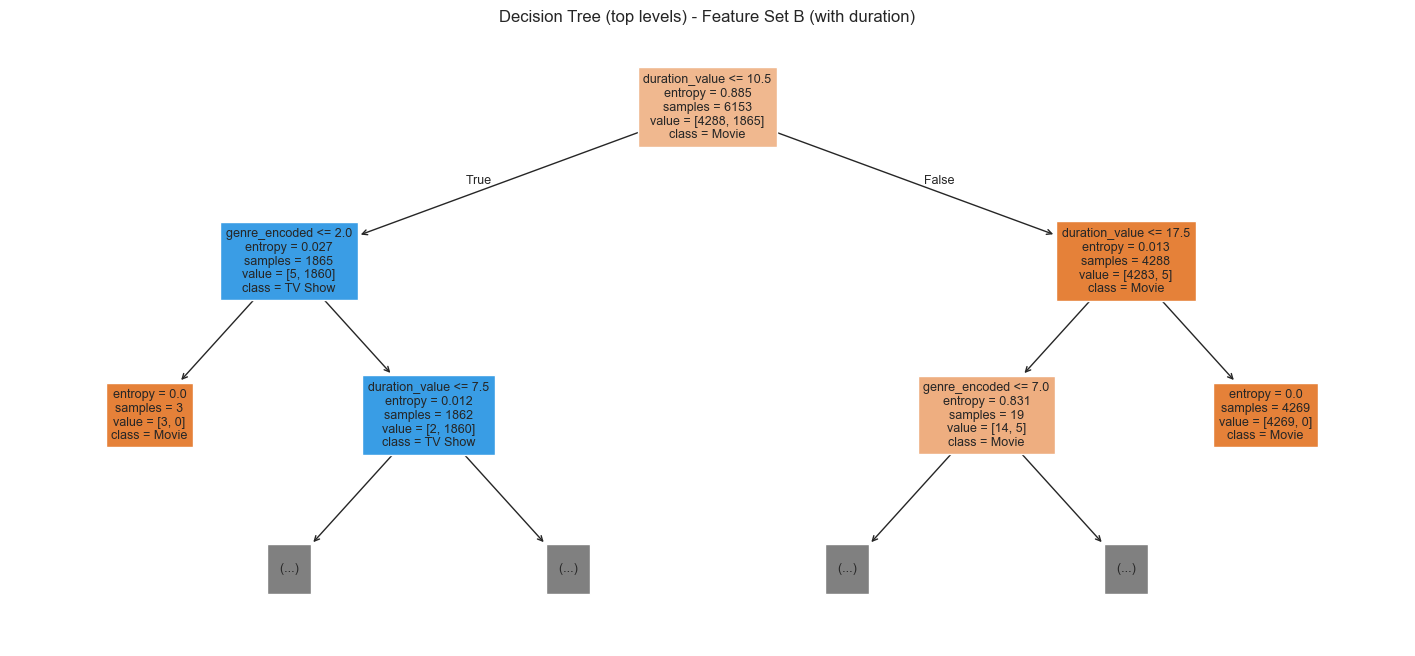

In [ ]:
# Visualise the top 3 levels of the Decision Tree (Feature Set B) to see
# which feature it splits on first -- we expect 'duration_value' to dominate
plt.figure(figsize=(18, 8))
plot_tree(dt_B, max_depth=2, feature_names=features_B, class_names=['Movie', 'TV Show'],
          filled=True, fontsize=9)
plt.title('Decision Tree (top levels) - Feature Set B (with duration)')
plt.show()

## 10. Random Forest Model

Random Forest builds a large number of individual decision trees on random
subsets of the data/features, and combines their votes to make a final,
usually more robust, prediction.

In [ ]:
# Random Forest - Feature Set A (without duration)
rf_A = RandomForestClassifier(n_estimators=200, random_state=42)
rf_A.fit(X_A_train, y_train)
y_pred_rf_A = rf_A.predict(X_A_test)
acc_rf_A = accuracy_score(y_test, y_pred_rf_A)

print("Random Forest accuracy (without duration):", round(acc_rf_A, 4))
print(classification_report(y_test, y_pred_rf_A, target_names=['Movie', 'TV Show']))

Random Forest accuracy (without duration): 0.9784
              precision    recall  f1-score   support

       Movie       0.99      0.98      0.98      1838
     TV Show       0.95      0.98      0.97       799

    accuracy                           0.98      2637
   macro avg       0.97      0.98      0.97      2637
weighted avg       0.98      0.98      0.98      2637



In [ ]:
# Random Forest - Feature Set B (with duration)
rf_B = RandomForestClassifier(n_estimators=200, random_state=42)
rf_B.fit(X_B_train, y_train)
y_pred_rf_B = rf_B.predict(X_B_test)
acc_rf_B = accuracy_score(y_test, y_pred_rf_B)

print("Random Forest accuracy (with duration):", round(acc_rf_B, 4))
print(classification_report(y_test, y_pred_rf_B, target_names=['Movie', 'TV Show']))

Random Forest accuracy (with duration): 1.0
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1838
     TV Show       1.00      1.00      1.00       799

    accuracy                           1.00      2637
   macro avg       1.00      1.00      1.00      2637
weighted avg       1.00      1.00      1.00      2637



duration_value     0.691449
genre_encoded      0.259827
rating_encoded     0.028953
release_year       0.011254
country_encoded    0.006968
year_added         0.001548
dtype: float64


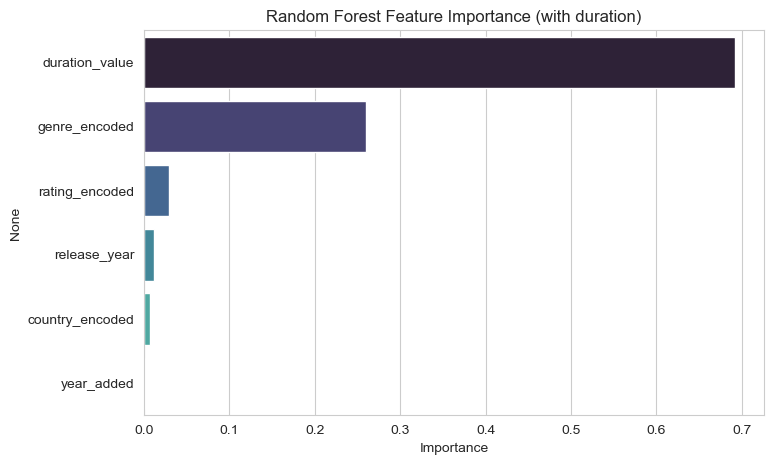

In [ ]:
# Analysis: feature importance from the Random Forest (Feature Set B)
# This shows numerically how dominant 'duration_value' is as a predictor
importances = pd.Series(rf_B.feature_importances_, index=features_B).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='mako', legend=False)
plt.title('Random Forest Feature Importance (with duration)')
plt.xlabel('Importance')
plt.show()

In [ ]:
# Summary table comparing all 3 algorithms across both feature sets
results = pd.DataFrame({
    'Without Duration': [acc_lr_A, acc_dt_A, acc_rf_A],
    'With Duration':    [acc_lr_B, acc_dt_B, acc_rf_B],
}, index=['Logistic Regression', 'Decision Tree', 'Random Forest']).round(4)

results

,Without Duration,With Duration
Logistic Regression,0.8343,0.9981
Decision Tree,0.9750,0.9992
Random Forest,0.9784,1.0000


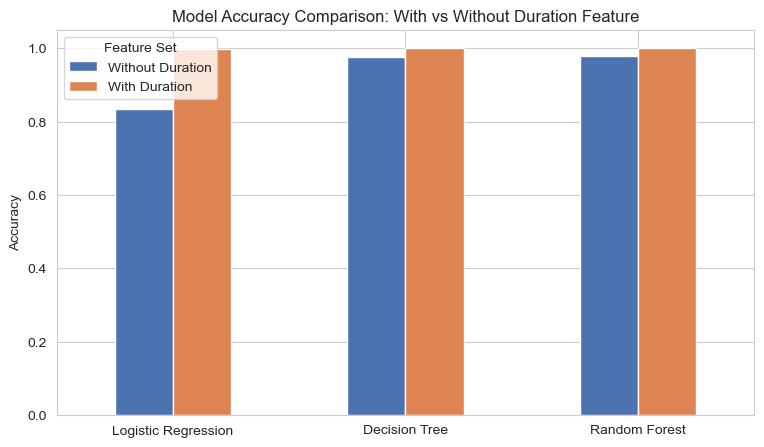

In [ ]:
# Visualisation: grouped bar chart comparing accuracy across models and feature sets
results.plot(kind='bar', figsize=(9, 5), color=['#4C72B0', '#DD8452'])
plt.title('Model Accuracy Comparison: With vs Without Duration Feature')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title='Feature Set')
plt.show()

## 12. Confusion Matrix (Best Model)

Random Forest without the duration feature performed best among the realistic
(non-leaky) models, so we inspect its confusion matrix in more detail.

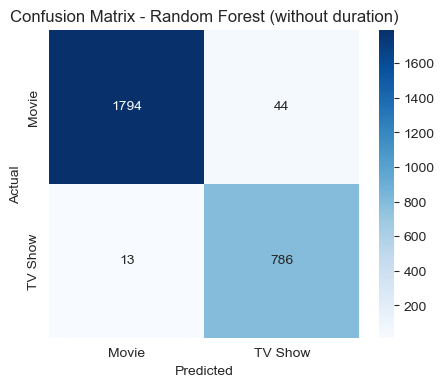

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf_A)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Movie', 'TV Show'], yticklabels=['Movie', 'TV Show'])
plt.title('Confusion Matrix - Random Forest (without duration)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 13. Conclusion

- All three algorithms performed reasonably well even **without** the duration
  feature (83-98% accuracy), with **Random Forest** performing best.
- Once `duration_value` is included, all three models jump to **99-100%**
  accuracy. This is a textbook case of a feature that leaks the target: a
  Netflix "duration" is measured in *minutes* for movies and *seasons* for TV
  shows, so its scale alone almost tells the model the answer.
- **Decision Tree and Random Forest** clearly outperform **Logistic
  Regression** on the "without duration" feature set, suggesting the
  relationship between genre/rating/country and content type is non-linear
  and better captured by tree-based splits.
- For a genuinely useful real-world model (e.g. predicting type for a new,
  unreleased title where duration/season count isn't yet known), Feature Set
  A ("without duration") is the more honest and meaningful model to report.